In [1]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='ticks',font_scale=1.25,palette='muted')

In [18]:
rdir = '/home/kat/Repos/SALSA/results/'

tag_salsa = '2022050220_salsa_2022041804_04_2000n_test_euc'
tag_contra = '2022050220_contra_2022041807_a03_2000n_test_euc'
tag_ae = '2022050220_ae_2022041809_a04_2000n_test_euc'
tag_fp = '2022050220_baseline_2000n_test_morgan_bitv_1024b_2r_eucnorm'

rows = []
for tag in [tag_salsa, tag_contra, tag_ae, tag_fp]:
    dists = np.loadtxt(f'{rdir}anc_aug_dists/{tag}.txt')
    version = tag.split('_')[1]
    for dist in dists:
        rows.append([version, dist])
        
df = pd.DataFrame(rows, columns=['method','Pairwise anc-aug distances'])

v_dict = {'salsa':'SALSA',
          'contra':'Contrastive encoder',
          'ae':'Vanilla autoencoder',
          'baseline': 'ECFPs (normalized)'}

df['method'] = df['method'].map(v_dict)

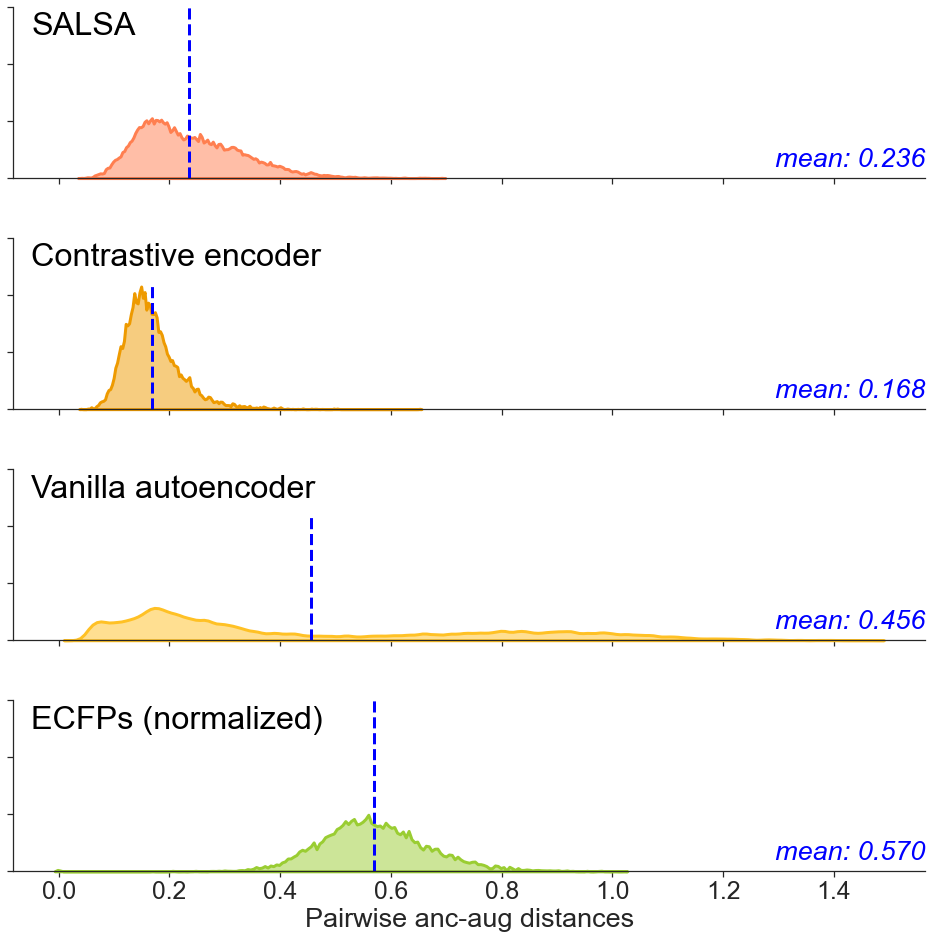

In [19]:
# source: https://stackoverflow.com/questions/59058641/...
# ... seaborn-facet-grid-adding-horizontal-mean-line-to-each-plt-plot-facet
def custom_vline(y, **kwargs):
    ym = y.mean()
    c = 'blue'
    plt.axvline(ym, color=c, linestyle="dashed",linewidth=3)
    plt.annotate(f"mean: {y.mean():.3f}", xy=(1,1), fontstyle="italic",
                 xycoords=plt.gca().get_yaxis_transform(), ha="right",color=c)
    
# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
    ax = plt.gca()
    t = ax.get_yaxis_transform()
    props = dict(boxstyle='square', facecolor='white', alpha=1., linewidth=1, edgecolor='white')
    ax.text(0.02, 12, label, fontsize='large', color='black',
            ha="left", va="bottom", transform=t, bbox=props)
    
    
# # # # # # # # # # # #
sns.set_theme(style='ticks',font_scale=2.25,palette='muted')

h = 3.5
asp = 4
pal = ['coral', '#EE9A00', '#FFC125','yellowgreen'] #  '#7D9EC0']

g = sns.FacetGrid(df, row="method", hue="method", aspect=asp, height=h, palette=pal)

# Draw the densities.
g.map(sns.kdeplot, "Pairwise anc-aug distances",
      clip_on=False, bw_adjust=.15,
      fill=True, alpha=.5, linewidth=3) # 1.5)
g.set_yticklabels([])

g.map(custom_vline,"Pairwise anc-aug distances")
g.map(label, "Pairwise anc-aug distances")

g.set_titles("")
g.set(ylabel="")
g.despine(bottom=False, left=False)
plt.savefig("anc_aug_dists_comparison_alpha_pt5.png")
display()